In [3]:
# =============================================
# TASK 3: SENTIMENT ANALYSIS & CORRELATION
# =============================================

import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

print(" Libraries imported")

 Libraries imported


In [24]:
# ======================
# 1. Load News & Stock Data
# ======================

# Load News Data
news = pd.read_csv('../data/newsData/raw_analyst_ratings.csv')
news = news.drop(columns=['Unnamed: 0'])
news['date'] = pd.to_datetime(news['date'], format='mixed', utc=True).dt.tz_convert(None)
news['date_only'] = news['date'].dt.date

print("News Shape:", news.shape)

News Shape: (1407328, 6)


In [25]:
# ======================
# 2. Sentiment Analysis (OPTIMIZED)
# ======================

from textblob import TextBlob
import pandas as pd

# Use a SAMPLE first for quick testing (Highly Recommended)
sample_size = 20000   # Change to 50000 later if needed
news_sample = news.sample(n=sample_size, random_state=42).copy()

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity # type: ignore

print("Calculating sentiment on sample...")
news_sample['sentiment'] = news_sample['headline'].apply(get_sentiment)

news_sample['sentiment_category'] = news_sample['sentiment'].apply(
    lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral')
)

print("Sentiment Analysis Completed on Sample!")
print(news_sample[['headline', 'sentiment', 'sentiment_category']].head(10))
print("\nSentiment Distribution:")
print(news_sample['sentiment_category'].value_counts(normalize=True) * 100)

Calculating sentiment on sample...
Sentiment Analysis Completed on Sample!
                                                  headline  sentiment  \
1201723  Syntel, Inc. Reports Q1 EPS of $1.11 vs $1.03 ...      0.000   
1282616  Mid-Day Market Update: K2M Group Rises On Acqu...      0.000   
554075   Aramchol's Failed Past Isn't Its Future; Galme...     -0.250   
1190332     60 Stocks Moving In Thursday's Mid-Day Session      0.000   
192958   Anheuser-Busch shares are trading lower after ...      0.000   
996906          The Market In 5 Minutes: Don't Stop Me Now      0.000   
606689   Hawaiian Electric Industries, Inc. Reports Q3 ...      0.000   
821630   Valuation Flies Higher On Macquarie Infrastruc...      0.250   
362771   DISH Network Reports Q2 EPS $0.75 vs $0.79 Est...      0.000   
258731   21st Century Fox Rejected Higher Offer From Co...      0.125   

        sentiment_category  
1201723            Neutral  
1282616            Neutral  
554075            Negative  
11903

In [26]:
# ======================
# 3. Prepare Stock Data (Example: AAPL)
# ======================

import yfinance as yf

stock = 'AAPL'
price_data = yf.download(stock, start="2020-01-01", end="2020-12-31", progress=False)

# yfinance can return MultiIndex columns (e.g., ('AAPL','Close')). Flatten to 1 level.
if isinstance(price_data.columns, pd.MultiIndex):
    price_data.columns = price_data.columns.get_level_values(-1)

price_data = price_data.rename(columns={'Adj Close': 'Close'}) # type: ignore

# Calculate Daily Returns
price_data['daily_return'] = price_data['Close'].pct_change() * 100

print("Stock data downloaded!")

Stock data downloaded!


In [29]:
# ======================
# 4. Merge News Sentiment with Stock Returns
# ======================

# Sentiment needs to exist on the SAME dataframe we aggregate.
# To keep this fast, compute sentiment only for the selected stock's headlines.
stock_news = news[news['stock'] == stock].copy()

# Optional: restrict to the stock price date range (speeds up a lot)
start_d = price_data.index.min().date()
end_d = price_data.index.max().date()
stock_news = stock_news[(stock_news['date_only'] >= start_d) & (stock_news['date_only'] <= end_d)].copy()

if 'sentiment' not in stock_news.columns:
    stock_news['sentiment'] = stock_news['headline'].apply(get_sentiment)

# Aggregate sentiment per day
daily_sentiment = (
    stock_news.groupby('date_only', as_index=False)['sentiment']
    .mean()
    .rename(columns={'date_only': 'Date'})
)

# Make sure both sides use the same type for Date (python date)
price_df = price_data.reset_index().copy()

# If yfinance produced MultiIndex columns, flatten them here as well
if isinstance(price_df.columns, pd.MultiIndex):
    price_df.columns = [
        (c[0] if (len(c) > 0 and (c[0] not in (None, ''))) else c[-1])
        if isinstance(c, tuple) else c
        for c in price_df.columns
    ]
    # If still tuple-like, join levels into a single string
    price_df.columns = [
        "_".join([str(x) for x in c if str(x) not in ("", "None")]).strip("_")
        if isinstance(c, tuple) else str(c)
        for c in price_df.columns
    ]

# Ensure we have a clean 'Date' column
if 'Date' not in price_df.columns:
    # common fallback if it became something like ('Date','')
    date_cols = [c for c in price_df.columns if str(c).lower().startswith('date')]
    if date_cols:
        price_df = price_df.rename(columns={date_cols[0]: 'Date'})

price_df['Date'] = pd.to_datetime(price_df['Date']).dt.date

merged = price_df.merge(daily_sentiment, on='Date', how='left')
merged['sentiment'] = merged['sentiment'].fillna(0)  # No news = neutral

print("Merged Shape:", merged.shape)
print(merged[['Date', 'Close', 'daily_return', 'sentiment']].head())

Merged Shape: (252, 8)
         Date      Close  daily_return  sentiment
0  2020-01-02  72.333878           NaN        0.0
1  2020-01-03  71.630646     -0.972203        0.0
2  2020-01-06  72.201416      0.796824        0.0
3  2020-01-07  71.861832     -0.470329        0.0
4  2020-01-08  73.017838      1.608651        0.0


Pearson Correlation between Sentiment and Daily Return: 0.1064


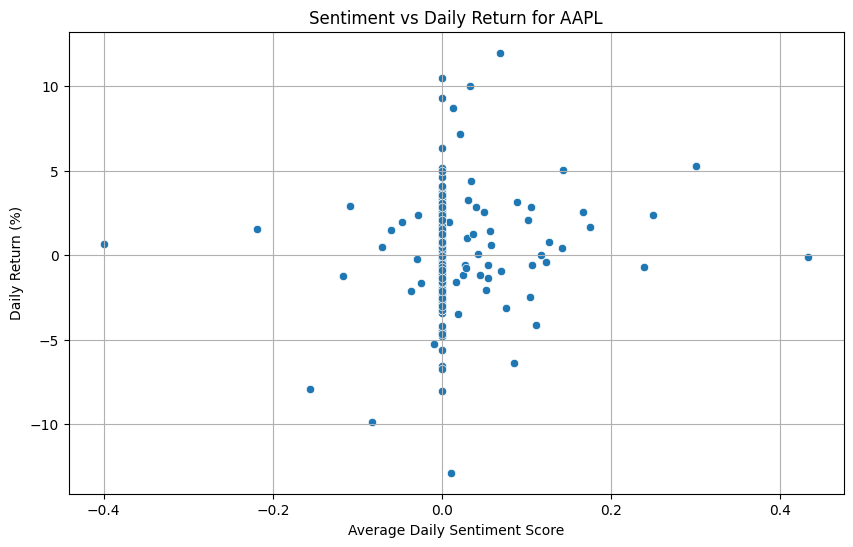

In [30]:
# ======================
# 5. Correlation Analysis
# ======================

correlation = merged['sentiment'].corr(merged['daily_return'])
print(f"Pearson Correlation between Sentiment and Daily Return: {correlation:.4f}")

# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='sentiment', y='daily_return')
plt.title(f'Sentiment vs Daily Return for {stock}')
plt.xlabel('Average Daily Sentiment Score')
plt.ylabel('Daily Return (%)')
plt.grid(True)
plt.show()


Average Daily Return by Sentiment:
sentiment_cat
Negative   -1.490491
Neutral     0.293838
Positive    0.679413
Name: daily_return, dtype: float64


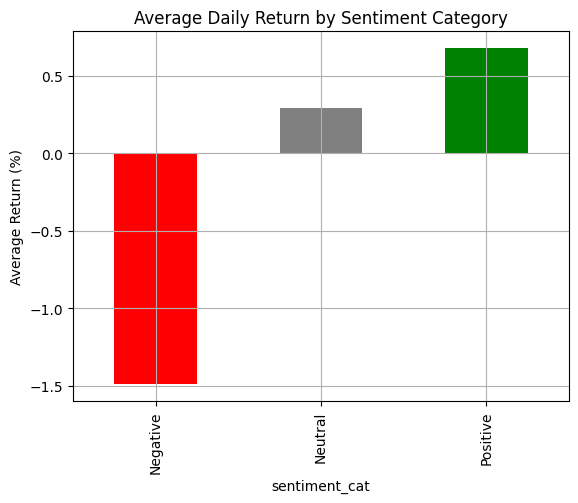

In [31]:
# Average Return by Sentiment Category
merged['sentiment_cat'] = pd.cut(merged['sentiment'], 
                                 bins=[-1, -0.05, 0.05, 1], 
                                 labels=['Negative', 'Neutral', 'Positive'])

avg_return = merged.groupby('sentiment_cat')['daily_return'].mean()
print("\nAverage Daily Return by Sentiment:")
print(avg_return)

# Bar Plot
avg_return.plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Average Daily Return by Sentiment Category')
plt.ylabel('Average Return (%)')
plt.grid(True)
plt.show()